# Fruit Classification - 01: EDA

Classify photos of fruit into their type. The dataset is a subset of **fruits-360** (HuggingFace `PedroSampaio/fruits-360`): studio photos of single fruits on a white background. We ship a committed 64x64 sample under `data/sample/<fruit>/` so the notebook runs offline; the full dataset has 113 fruit classes.

In [1]:
import sys, numpy as np
import matplotlib.pyplot as plt
sys.path.append('.')
import utils
imgs, labels, classes = utils.load_sample()
print('classes:', classes)
print('total images:', len(imgs))

classes: ['Apple', 'Avocado', 'Banana', 'Kiwi', 'Lemon', 'Orange', 'Pineapple', 'Strawberry']
total images: 1124


## 1. Class balance

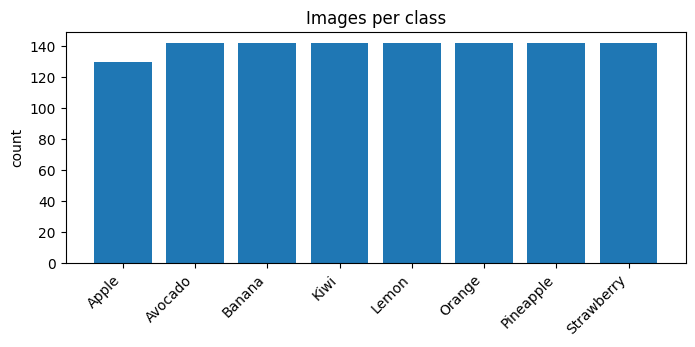

Apple          130
Avocado        142
Banana         142
Kiwi           142
Lemon          142
Orange         142
Pineapple      142
Strawberry     142


In [2]:
import collections
cnt = collections.Counter(labels)
plt.figure(figsize=(8,3)); plt.bar(list(cnt.keys()), list(cnt.values()))
plt.xticks(rotation=45, ha='right'); plt.ylabel('count'); plt.title('Images per class'); plt.show()
for k in classes: print('%-14s %d' % (k, cnt[k]))

## 2. One sample per class

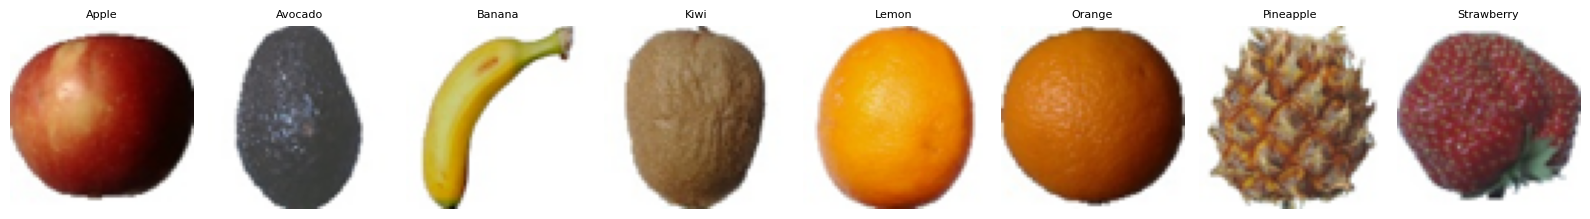

In [3]:
fig, ax = plt.subplots(1, len(classes), figsize=(2*len(classes), 2.4))
seen=set()
for im,l in zip(imgs,labels):
    if l in seen: continue
    seen.add(l); a=ax[classes.index(l)]; a.imshow(im); a.set_title(l, fontsize=8); a.axis('off')
plt.tight_layout(); plt.show()

## 3. A grid from one class

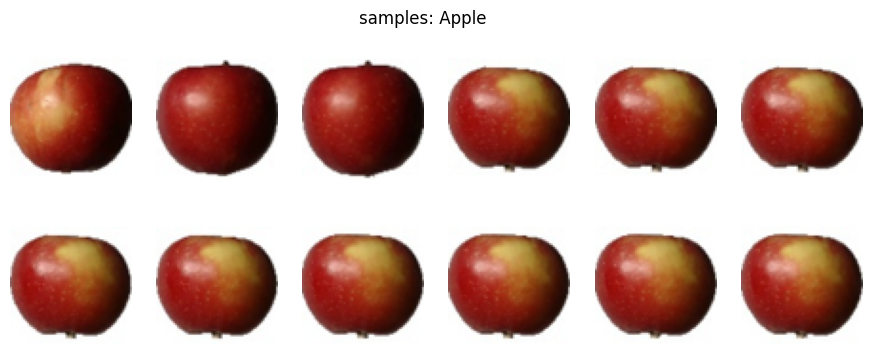

In [4]:
target = classes[0]
sel = [im for im,l in zip(imgs,labels) if l==target][:12]
fig, ax = plt.subplots(2,6, figsize=(11,4))
for a,im in zip(ax.ravel(), sel): a.imshow(im); a.axis('off')
plt.suptitle('samples: '+target); plt.show()

### Findings
Fruits are photographed cleanly on white, so classes are visually distinct. This is close to the easy end of image classification, which makes it a good first transfer-learning demo.